<strong><center><h1>Energy Consumption Forecasting</center></strong></h1>
<h3><center>Lab Notebook</center></h3> 

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import holidays
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.deterministic import Fourier
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.gofplots import qqplot
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# 0. Dataset Loading & Initial Exploration

In [23]:
path = "household_power_consumption.txt"
df = pd.read_csv(
    path,
    sep=";",
    na_values="?",
    low_memory=False
)

print("Number of rows in the dataset: ", df.shape[0])
print("Number of columns in the dataset: ", df.shape[1])
print("Columns in the dataset: ", df.columns.tolist())
print("First 5 rows of the dataset: ")
print(df.head())

Number of rows in the dataset:  2075259
Number of columns in the dataset:  9
Columns in the dataset:  ['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
First 5 rows of the dataset: 
         Date      Time  Global_active_power  Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00                4.216                  0.418   234.84   
1  16/12/2006  17:25:00                5.360                  0.436   233.63   
2  16/12/2006  17:26:00                5.374                  0.498   233.29   
3  16/12/2006  17:27:00                5.388                  0.502   233.74   
4  16/12/2006  17:28:00                3.666                  0.528   235.68   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
0              18.4             0.0             1.0            17.0  
1              23.0             0.0             1.0            16.0  
2              23.0        

# 1. Data Preprocessing

### 1.1. Converting Date & Time to Datetime Index

In [24]:
# Parse into datetime index
df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"], format="%d/%m/%Y %H:%M:%S")
df.set_index("datetime", inplace=True)

# Drop the original columns
df.drop(columns=["Date", "Time"], inplace=True)

# Inspect
df.index.name, df.columns.tolist()

df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


### 1.2. Convert Columns to Numeric & Handle Missing Values

In [25]:
print("Missing values in the dataset: ")
print(df.isna().sum())

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df.fillna(method="ffill", inplace=True)

# Verify no remaining NaNs
print("Missing values after filling: ")
print(df.isna().sum())

Missing values in the dataset: 
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64
Missing values after filling: 
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


C:\Users\elati\AppData\Local\Temp\ipykernel_1936\769306230.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


### 1.3. Resample to Hourly, Daily, and Weekly Data

In [26]:
# 4. Resample to different frequencies

# Hourly mean
df_hourly = df.resample("H").mean()

# Daily mean
df_daily = df.resample("D").mean()

# Weekly mean (Monday start)
df_weekly = df.resample("W-MON").mean()

# Show samples
print("Hourly:", df_hourly.iloc[:3].to_dict(orient="records"))
print("Daily:",  df_daily.iloc[:3].to_dict(orient="records"))
print("Weekly:", df_weekly.iloc[:3].to_dict(orient="records"))

C:\Users\elati\AppData\Local\Temp\ipykernel_1936\1622640499.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample("H").mean()


Hourly: [{'Global_active_power': 4.222888888888889, 'Global_reactive_power': 0.22899999999999998, 'Voltage': 234.6438888888889, 'Global_intensity': 18.1, 'Sub_metering_1': 0.0, 'Sub_metering_2': 0.5277777777777778, 'Sub_metering_3': 16.86111111111111}, {'Global_active_power': 3.6321999999999997, 'Global_reactive_power': 0.08003333333333333, 'Voltage': 234.58016666666666, 'Global_intensity': 15.6, 'Sub_metering_1': 0.0, 'Sub_metering_2': 6.716666666666667, 'Sub_metering_3': 16.866666666666667}, {'Global_active_power': 3.4002333333333334, 'Global_reactive_power': 0.08523333333333333, 'Voltage': 233.23250000000002, 'Global_intensity': 14.503333333333334, 'Sub_metering_1': 0.0, 'Sub_metering_2': 1.4333333333333333, 'Sub_metering_3': 16.683333333333334}]
Daily: [{'Global_active_power': 3.0534747474747475, 'Global_reactive_power': 0.08818686868686867, 'Voltage': 236.24376262626262, 'Global_intensity': 13.082828282828283, 'Sub_metering_1': 0.0, 'Sub_metering_2': 1.378787878787879, 'Sub_meteri

# 2. Exploratory Data Analysis

### 2.1 Temporal Consumption Patterns

Visualize the average global active power by hour of day, day of week, and month to understand the household’s daily and seasonal usage rhythms.

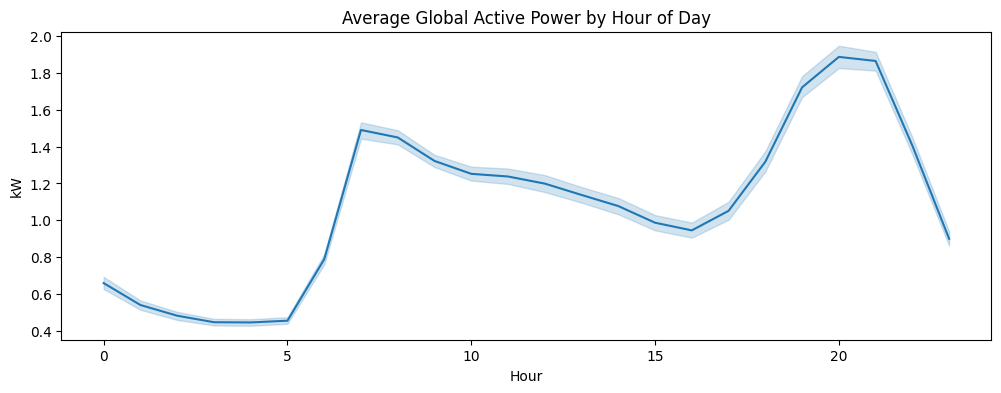

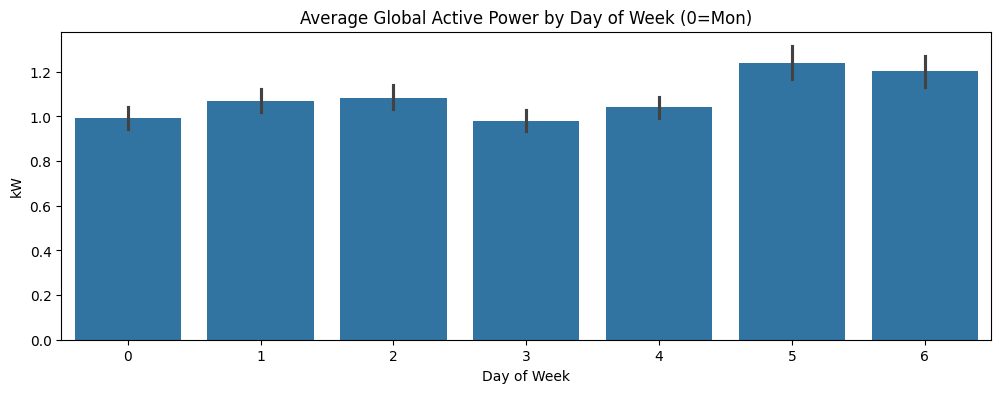

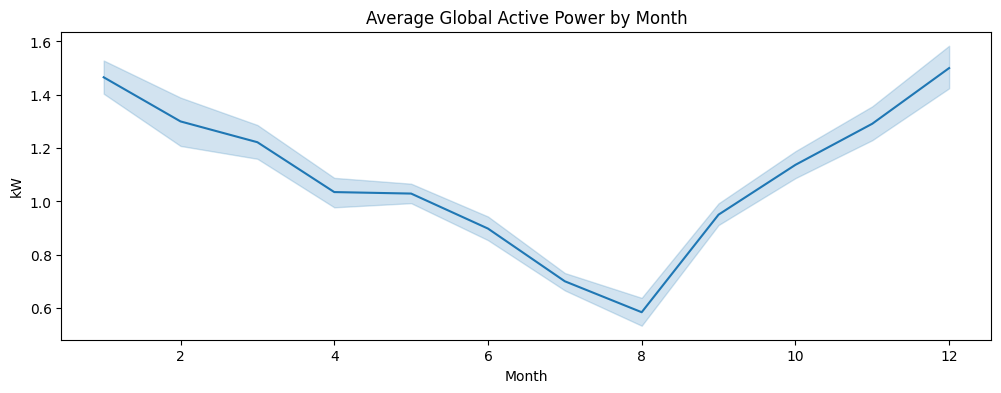

In [27]:
plt.figure(figsize=(12,4))
sns.lineplot(x=df_hourly.index.hour, y=df_hourly['Global_active_power'], estimator='mean')
plt.title('Average Global Active Power by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('kW')
plt.show()

plt.figure(figsize=(12,4))
sns.barplot(x=df_daily.index.dayofweek, y=df_daily['Global_active_power'])
plt.title('Average Global Active Power by Day of Week (0=Mon)')
plt.xlabel('Day of Week')
plt.ylabel('kW')
plt.show()

plt.figure(figsize=(12,4))
sns.lineplot(x=df_daily.index.month, y=df_daily['Global_active_power'], estimator='mean')
plt.title('Average Global Active Power by Month')
plt.xlabel('Month')
plt.ylabel('kW')
plt.show()

### 2.2 Correlation Analysis

Compute the Pearson correlation matrix for all power consumption features and visualize it as a heatmap to uncover relationships and potential multicollinearity among variables.

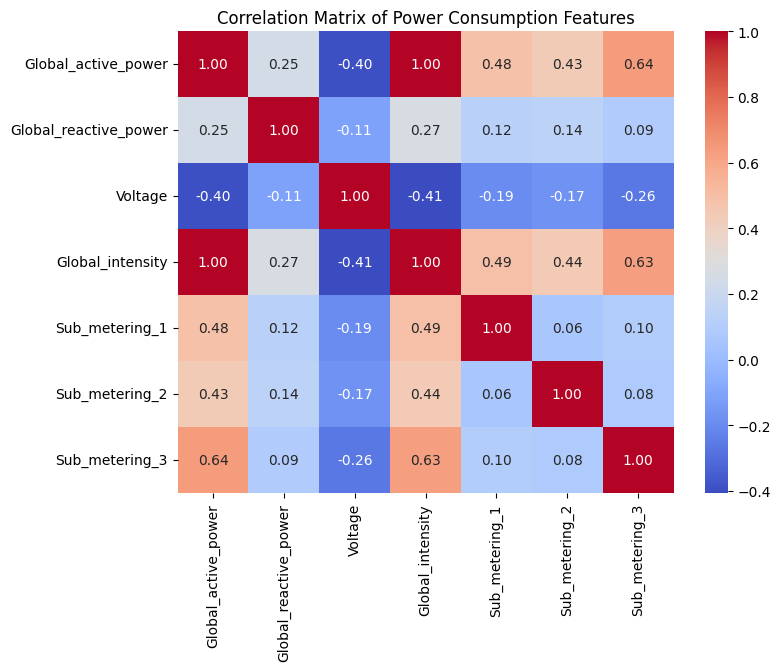

In [28]:
corr = df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix of Power Consumption Features')
plt.show()

### 2.3 Decompose Time Series Components

Break down the daily global active power series into its observed, trend, seasonal, and residual components using an additive model with a 365-day period. This helps reveal long-term trends, seasonal cycles, and any irregular fluctuations.

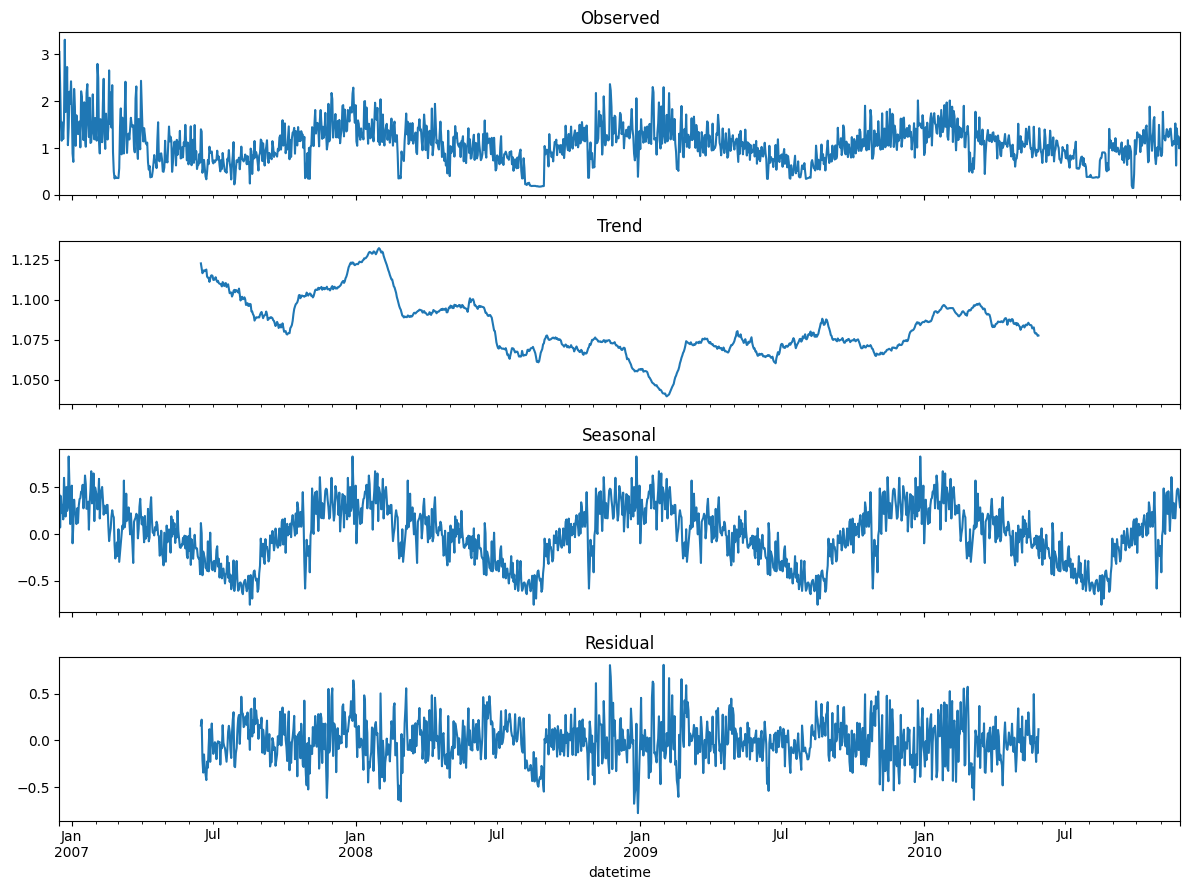

In [29]:
decomp = seasonal_decompose(df_daily['Global_active_power'], model='additive', period=365)
fig, axes = plt.subplots(4,1, figsize=(12,9), sharex=True)
decomp.observed.plot(ax=axes[0], title='Observed')
decomp.trend.plot(ax=axes[1], title='Trend')
decomp.seasonal.plot(ax=axes[2], title='Seasonal')
decomp.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()
plt.show()

# 3. Features Engineering

Enrich the daily-aggregated series (`df_daily`) by adding:
- **Calendar features** (`dayofweek`, `month`, `year`)
- **French holiday flag** (`is_holiday`)
- **Rolling statistics** over a 7-day window (`roll_mean_7d`, `roll_std_7d`)
- **Lag features** to capture autocorrelation (`lag_1d`, `lag_7d`, `lag_14d`)

Rows containing `NaN` (from rolling and lag operations) are dropped to yield the final feature set `df_feat`.

In [30]:
# 1. Time-based features
df_daily['dayofweek'] = df_daily.index.dayofweek       # 0=Monday … 6=Sunday
df_daily['month']     = df_daily.index.month          # 1–12
df_daily['year']      = df_daily.index.year

# 2. French holiday indicator
fr_hols = holidays.France(years=df_daily.index.year.unique())
df_daily['is_holiday'] = df_daily.index.normalize().isin(fr_hols).astype(int)

# 3. Rolling statistics (7-day window)
df_daily['roll_mean_7d'] = df_daily['Global_active_power'].rolling(7).mean()
df_daily['roll_std_7d']  = df_daily['Global_active_power'].rolling(7).std()

# 4. Lag features
df_daily['lag_1d']  = df_daily['Global_active_power'].shift(1)
df_daily['lag_7d']  = df_daily['Global_active_power'].shift(7)
df_daily['lag_14d'] = df_daily['Global_active_power'].shift(14)

# Drop rows with NaNs introduced above
df_feat = df_daily.dropna()

df_feat.head()

C:\Users\elati\AppData\Local\Temp\ipykernel_1936\2959321821.py:8: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df_daily['is_holiday'] = df_daily.index.normalize().isin(fr_hols).astype(int)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,dayofweek,month,year,is_holiday,roll_mean_7d,roll_std_7d,lag_1d,lag_7d,lag_14d
datetime,,,,,,,,,,,,,,,,
2006-12-30,1.945651,0.217192,240.536326,8.317083,2.186111,5.506250,8.691667,5,12,2006,0,1.865553,0.533930,2.204439,3.314851,3.053475
2006-12-31,2.426525,0.104758,239.896576,10.199583,0.000000,0.240972,4.515278,6,12,2006,0,1.959222,0.570788,1.945651,1.770842,2.354486
2007-01-01,1.909031,0.102893,240.128979,7.916944,0.000000,0.244444,4.083333,0,1,2007,1,1.959805,0.570725,2.426525,1.904944,1.530435
2007-01-02,0.881414,0.132182,241.943778,3.714028,0.000000,0.241667,4.556944,1,1,2007,0,1.695433,0.581911,1.909031,2.732021,1.157079
2007-01-03,0.704204,0.136617,243.557090,3.014028,0.000000,0.238889,3.309028,2,1,2007,0,1.644371,0.657560,0.881414,1.061639,1.545658


# 4. Model Development and Comparison

### 4.1. Statistical Model: SARIMAX

In [31]:
# 1) Log‐transform & split
y_log       = np.log1p(df_daily['Global_active_power'])      # stabilize variance with log1p
train, test = y_log[:-365], y_log[-365:]                     # last 365 days as hold­out
idx_train, idx_test = train.index, test.index                # save indices for exog alignment
roll7_all = y_log.rolling(window=7, min_periods=1).mean()
fr_hols   = holidays.France(years=df_daily.index.year.unique())
flags_all = pd.DataFrame({
    'is_weekend': (df_daily.index.weekday >= 5).astype(int),
    'is_holiday': df_daily.index.normalize().isin(fr_hols).astype(int)
}, index=df_daily.index)

# 2) Build refined Fourier bases for seasonality
four_yr = Fourier(period=365, order=3)                       # annual cycle (3 harmonics)
four_wk = Fourier(period=7,   order=3)                       # weekly cycle (3 harmonics)
f_yr_all = four_yr.in_sample(df_daily.index)                 # compute annual terms for full span
f_wk_all = four_wk.in_sample(df_daily.index)                 # compute weekly terms for full span

# 3) Rebuild exogenous DataFrame
exog_all_refined = pd.concat([
    pd.DataFrame(f_yr_all, index=df_daily.index).add_prefix("Yr_"),   # annual Fourier columns
    pd.DataFrame(f_wk_all, index=df_daily.index).add_prefix("Wk_"),   # weekly Fourier columns
    flags_all,                                                       # weekend & holiday flags
    roll7_all.rename("roll7"),                                       # local 7-day trend
    df_daily[['Global_reactive_power','Voltage','Sub_metering_3']]   # additional power channels
], axis=1)

# 4) Split & clean exogenous arrays
exog_train_r = np.nan_to_num(exog_all_refined.iloc[:-365].values)  # training exog
exog_test_r  = np.nan_to_num(exog_all_refined.iloc[-365:].values)  # test exog

# 5) Fit SARIMAX with no built-in seasonality (we handle it via exog)
model_r = SARIMAX(
    train,
    exog=exog_train_r,
    order=(1,1,1),               # ARIMA(p,d,q) = (1,1,1)
    seasonal_order=(0,0,0,0),    # no seasonal ARMA component
    trend='n',                   # no intercept/drift
    enforce_stationarity=False,  
    enforce_invertibility=False
)
res_r = model_r.fit(disp=False, maxiter=100)  # fit model (limit to 100 iterations)

# 6) Forecast & invert transform
pred_log_r = res_r.predict(
    start=idx_test[0], end=idx_test[-1],
    exog=exog_test_r
)
pred_r = np.expm1(pred_log_r)                           # back to original scale
actual = df_daily['Global_active_power'].loc[idx_test]  # actual hold-out values

# 7) Compute metrics & plot results
sarima_rmse = np.sqrt(mean_squared_error(actual, pred_r))    # root mean squared error
sarima_mae  = mean_absolute_error(actual, pred_r)            # mean absolute error
sarima_mape = np.mean(np.abs((actual - pred_r) / actual)) * 100  # mean absolute percentage error

print(f"SARIMA RMSE : {sarima_mae:.3f}")
print(f"SARIMA MAE  : {sarima_mae:.3f}")
print(f"SARIMA MAPE : {sarima_mape:.2f}%")

C:\Users\elati\AppData\Local\Temp\ipykernel_1936\1789853372.py:9: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  'is_holiday': df_daily.index.normalize().isin(fr_hols).astype(int)


SARIMA RMSE : 0.148
SARIMA MAE  : 0.148
SARIMA MAPE : 15.06%


c:\Users\elati\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### 4.2. Machine Learning Model: Random Forest Regressor

In [32]:
X = df_feat.drop(columns=['Global_active_power'])       # feature matrix
y = df_feat['Global_active_power']                      # target series

# 1) Set up time‐aware cross‐validation to avoid data leakage
tscv = TimeSeriesSplit(n_splits=5)

# 2) Define hyperparameter grid for tuning
param_grid = {
    'n_estimators':    [100, 200],  # number of trees
    'max_depth':       [5, 10, 15], # maximum tree depth
    'min_samples_leaf':[5, 10, 20], # min samples required at each leaf
    'max_features':    ['sqrt', 0.5]# features considered at each split
}

# 3) Instantiate RF and GridSearch over the time splits
rf      = RandomForestRegressor(random_state=42)
grid    = GridSearchCV(
    rf,
    param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error', # optimize for RMSE
    n_jobs=-1,
    verbose=1
)
grid.fit(X, y)                                 # run the grid search

best_rf = grid.best_estimator_                 # retrieve best model
print("Best RF params:", grid.best_params_)    # display best hyperparameters

# 4) Final evaluation on the last 365 days
train_size = len(X) - 365
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

best_rf.fit(X_train, y_train)                  # retrain on full train set
rf_pred = best_rf.predict(X_test)              # make predictions

# 5) Compute error metrics
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_mape = np.mean(np.abs((y_test - rf_pred) / y_test)) * 100

print(f"Random Forest RMSE : {rf_mae:.3f}")
print(f"Random Forest MAE  : {rf_mae:.3f}")
print(f"Random Forest MAPE : {rf_mape:.2f}%")


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best RF params: {'max_depth': 15, 'max_features': 0.5, 'min_samples_leaf': 5, 'n_estimators': 200}
Random Forest RMSE : 0.020
Random Forest MAE  : 0.020
Random Forest MAPE : 2.51%


### 4.3. Deep Learning Model: LSTM

In [33]:
# 1) Extract series and scale to [0,1]
series = df_daily['Global_active_power'].values.reshape(-1, 1)
scaler = MinMaxScaler()
series_scaled = scaler.fit_transform(series).flatten()  # flatten to 1D array

# 2) Build input/output sequences of length SEQ_LEN
SEQ_LEN = 14
X_seq, y_seq = [], []
for i in range(len(series_scaled) - SEQ_LEN):
    X_seq.append(series_scaled[i : i + SEQ_LEN])  # last 14 days
    y_seq.append(series_scaled[i + SEQ_LEN])      # next day
X_seq = np.array(X_seq)  # shape (samples, seq_len)
y_seq = np.array(y_seq)

# 3) Split into train / val / test
TEST_SIZE = 365
VAL_SIZE  = 100
train_end = len(X_seq) - (TEST_SIZE + VAL_SIZE)
val_end   = len(X_seq) - TEST_SIZE
X2_train, y2_train = X_seq[:train_end], y_seq[:train_end]
X2_val,   y2_val   = X_seq[train_end:val_end], y_seq[train_end:val_end]
X2_test,  y2_test  = X_seq[val_end:],      y_seq[val_end:]

# 4) Wrap in PyTorch Datasets & Loaders
BATCH_SIZE = 32
train_ds = TensorDataset(
    torch.Tensor(X2_train).unsqueeze(-1),  # add feature-dimension for LSTM
    torch.Tensor(y2_train)
)
val_ds   = TensorDataset(torch.Tensor(X2_val).unsqueeze(-1), torch.Tensor(y2_val))
test_ds  = TensorDataset(torch.Tensor(X2_test).unsqueeze(-1), torch.Tensor(y2_test))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

# 5) Define LSTM regression model
class LSTMRegressor(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=256, num_layers=1, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, hidden_dim, num_layers,
            batch_first=True, dropout=dropout
        )
        self.fc = nn.Linear(hidden_dim, 1)  # map last hidden state to output

    def forward(self, x):
        out, _ = self.lstm(x)              # out: (batch, seq_len, hidden_dim)
        return self.fc(out[:, -1, :])      # use the final time step

# 6) Instantiate model, loss, optimizer, scheduler
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
model     = LSTMRegressor().to(device)
criterion = nn.MSELoss()                  # mean squared error
optimizer = torch.optim.Adam(model.parameters(), lr=0.005) 
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5, verbose=True
)
epochs = 150

# 7) Training loop with validation
for epoch in range(epochs):
    print(f"Epoch {epoch+1}/{epochs}")
    print("-" * 20)
    # — Training phase —
    model.train()
    train_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device).unsqueeze(1)
        optimizer.zero_grad()
        preds = model(xb)                    # forward pass
        loss = criterion(preds, yb)          # compute loss
        loss.backward()                      # backpropagation
        optimizer.step()                     # update weights
        train_losses.append(loss.item())
    avg_train = np.mean(train_losses)

    # — Validation phase —
    model.eval()
    val_losses = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device).unsqueeze(1)
            preds = model(xb)
            val_losses.append(criterion(preds, yb).item())
    avg_val = np.mean(val_losses)

    scheduler.step(avg_val)  # adjust learning rate on plateau
    print(f"train_loss={avg_train:.4f}, val_loss={avg_val:.4f}")

# 8) Evaluate on test set
model.eval()
preds = []
with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        preds.append(model(xb).cpu().numpy().flatten())
preds = np.concatenate(preds)

# 9) Invert scaling and compute metrics
preds_inv   = scaler.inverse_transform(preds.reshape(-1, 1)).flatten()
y_test_inv  = scaler.inverse_transform(y2_test.reshape(-1, 1)).flatten()
lstm_rmse = np.sqrt(mean_squared_error(y_test_inv, preds_inv))
lstm_mae  = mean_absolute_error(y_test_inv, preds_inv)
lstm_mape = np.mean(np.abs((y_test_inv - preds_inv) / y_test_inv)) * 100

print(f"LSTM RMSE : {lstm_mae:.3f}")
print(f"LSTM MAE  : {lstm_mae:.3f}")
print(f"LSTM MAPE : {lstm_mape:.2f}%")

Using device: cuda


c:\Users\elati\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(
c:\Users\elati\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/150
--------------------
train_loss=0.0453, val_loss=0.0082
Epoch 2/150
--------------------
train_loss=0.0149, val_loss=0.0092
Epoch 3/150
--------------------
train_loss=0.0141, val_loss=0.0067
Epoch 4/150
--------------------
train_loss=0.0130, val_loss=0.0065
Epoch 5/150
--------------------
train_loss=0.0118, val_loss=0.0072
Epoch 6/150
--------------------
train_loss=0.0107, val_loss=0.0068
Epoch 7/150
--------------------
train_loss=0.0111, val_loss=0.0086
Epoch 8/150
--------------------
train_loss=0.0119, val_loss=0.0068
Epoch 9/150
--------------------
train_loss=0.0108, val_loss=0.0070
Epoch 10/150
--------------------
train_loss=0.0114, val_loss=0.0071
Epoch 11/150
--------------------
train_loss=0.0108, val_loss=0.0069
Epoch 12/150
--------------------
train_loss=0.0103, val_loss=0.0069
Epoch 13/150
--------------------
train_loss=0.0102, val_loss=0.0069
Epoch 14/150
--------------------
train_loss=0.0103, val_loss=0.0069
Epoch 15/150
--------------------
train_los

### 4.4. Model Performance Comparison

In [34]:
# 1. Build a summary table
results = {
    'SARIMA':        {'RMSE': sarima_rmse, 'MAE': sarima_mae, 'MAPE': sarima_mape},
    'RandomForest':  {'RMSE': rf_rmse,     'MAE': rf_mae,     'MAPE': rf_mape},
    'LSTM':          {'RMSE': lstm_rmse,   'MAE': lstm_mae,   'MAPE': lstm_mape}
}

comp_df = pd.DataFrame(results).T
print("Model performance comparison:")
display(comp_df)

# 2. Select best by RMSE
best_model = comp_df['RMSE'].idxmin()
best_rmse  = comp_df.loc[best_model, 'RMSE']
print(f"\n→ Best model by RMSE: **{best_model}** (RMSE = {best_rmse:.3f})")

Model performance comparison:


,RMSE,MAE,MAPE
SARIMA,0.203861,0.148490,15.061500
RandomForest,0.029122,0.019599,2.508029
LSTM,0.251564,0.185130,21.404606



→ Best model by RMSE: **RandomForest** (RMSE = 0.029)


# 5. Models Evaluation

### 5.1. Forecast vs. Actual

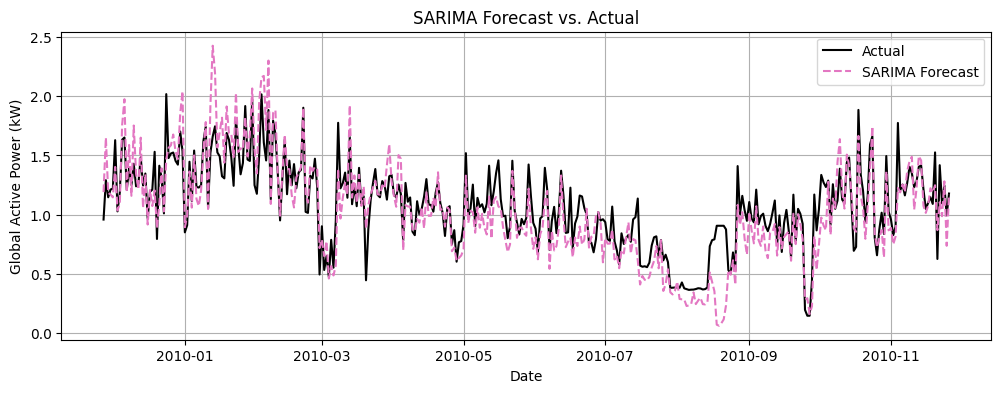

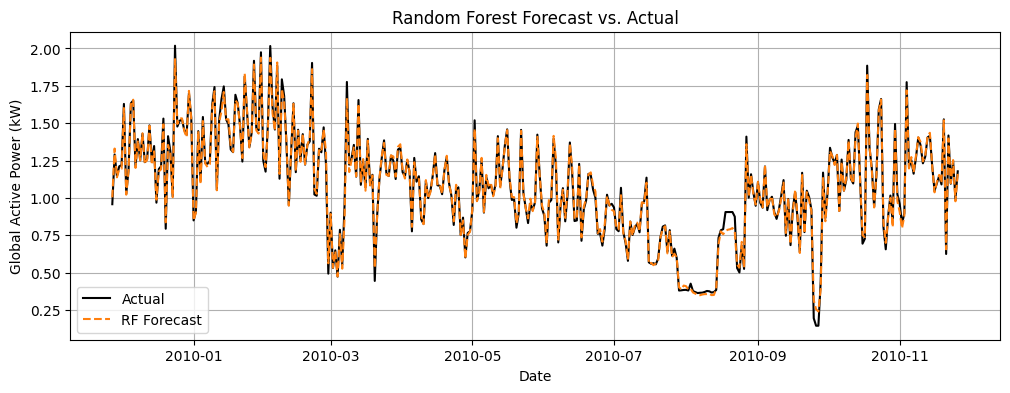

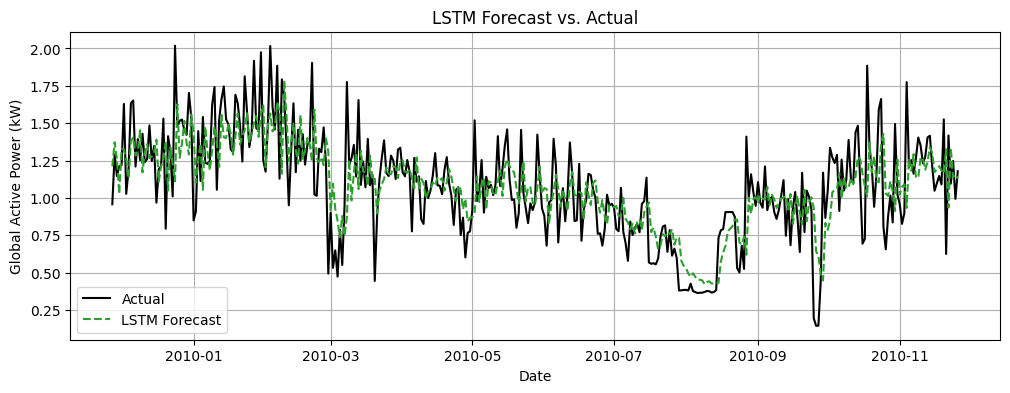

In [35]:
# Common settings
figsize = (12, 4)
actual_color = 'black'
line_width = 1.5

# 1) SARIMA
plt.figure(figsize=figsize)
plt.plot(idx_test, actual,      color=actual_color, linewidth=line_width, label='Actual')
plt.plot(idx_test, pred_r,      color='C6', linestyle='--',      linewidth=line_width, label='SARIMA Forecast')
plt.title('SARIMA Forecast vs. Actual')
plt.xlabel('Date'); plt.ylabel('Global Active Power (kW)')
plt.legend(); plt.grid(True)
plt.show()

# 2) Random Forest
plt.figure(figsize=figsize)
plt.plot(y_test.index, y_test,  color=actual_color, linewidth=line_width, label='Actual')
plt.plot(y_test.index, rf_pred, color='C1', linestyle='--',      linewidth=line_width, label='RF Forecast')
plt.title('Random Forest Forecast vs. Actual')
plt.xlabel('Date'); plt.ylabel('Global Active Power (kW)')
plt.legend(); plt.grid(True)
plt.show()

# 3) LSTM
lstm_idx = df_daily.index[-len(y_test_inv):]
plt.figure(figsize=figsize)
plt.plot(lstm_idx, y_test_inv,  color=actual_color, linewidth=line_width, label='Actual')
plt.plot(lstm_idx, preds_inv,   color='C2', linestyle='--',      linewidth=line_width, label='LSTM Forecast')
plt.title('LSTM Forecast vs. Actual')
plt.xlabel('Date'); plt.ylabel('Global Active Power (kW)')
plt.legend(); plt.grid(True)
plt.show()

### 5.2. Residual Distributions

Residual Summary Statistics:
            SARIMA          RF        LSTM
count  365.000000  365.000000  365.000000
mean     0.053323    0.002982   -0.001889
std      0.197034    0.029009    0.251902
min     -0.766761   -0.120780   -0.817262
25%     -0.043554   -0.012184   -0.145676
50%      0.065708    0.002155   -0.020916
75%      0.141948    0.013986    0.135973
max      0.844298    0.126386    0.906445 

Skewness:
 SARIMA    0.193883
RF        0.494869
LSTM      0.403334
dtype: float64 

Kurtosis:
 SARIMA    3.118271
RF        4.599156
LSTM      1.812843
dtype: float64 



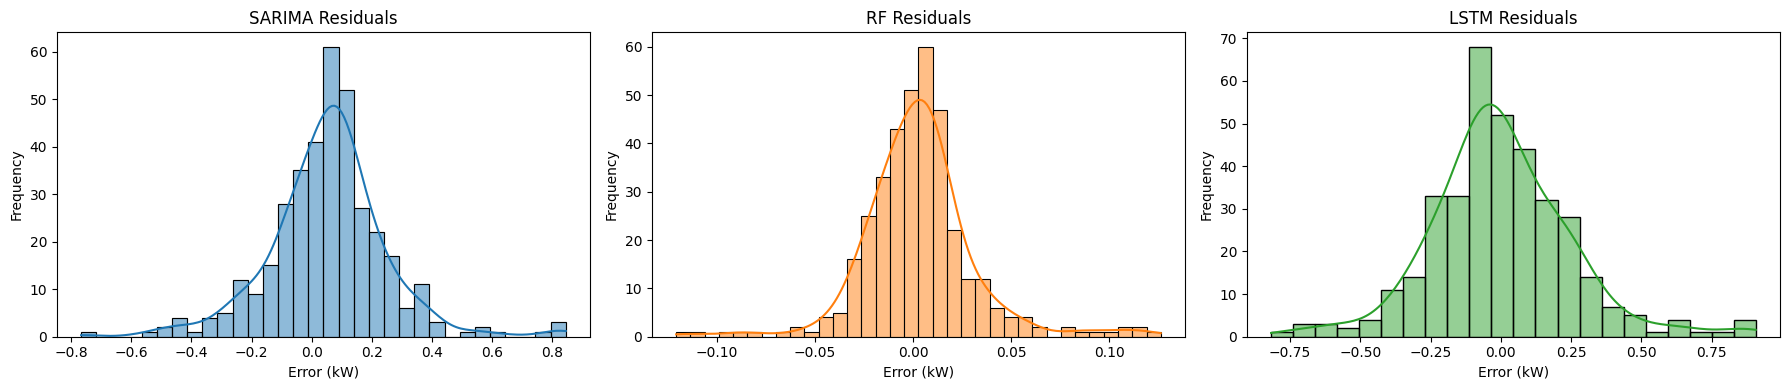

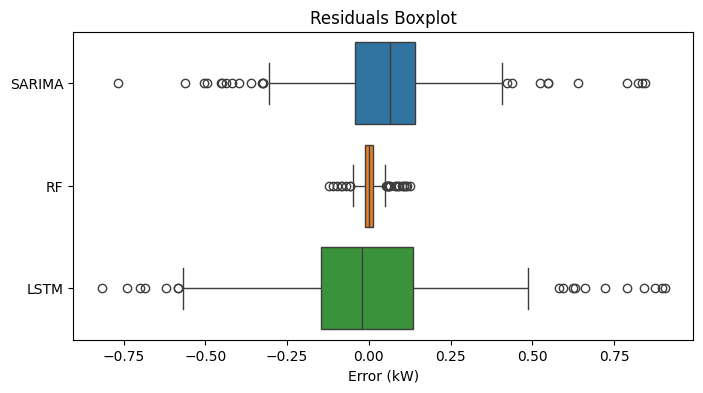

In [36]:
# 1) Compute residuals
resid_sarima = actual - pred_r
resid_rf     = y_test - rf_pred
resid_lstm   = pd.Series(y_test_inv - preds_inv, index=lstm_idx)

# 2) Combine into DataFrame
resid_df = pd.DataFrame({
    'SARIMA': resid_sarima,
    'RF':     resid_rf,
    'LSTM':   resid_lstm
})

# 3) Summary statistics
print("Residual Summary Statistics:\n", resid_df.describe(), "\n")
print("Skewness:\n", resid_df.skew(), "\n")
print("Kurtosis:\n", resid_df.kurtosis(), "\n")

# 4) Residual histograms with KDE
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col, color in zip(axes, resid_df.columns, ['C0','C1','C2']):
    sns.histplot(resid_df[col], kde=True, ax=ax, color=color)
    ax.set_title(f'{col} Residuals')
    ax.set_xlabel('Error (kW)')
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

# 5) Boxplot of residuals
plt.figure(figsize=(8,4))
sns.boxplot(data=resid_df, orient='h', palette=['C0','C1','C2'])
plt.title('Residuals Boxplot')
plt.xlabel('Error (kW)')
plt.show()

### 5.3. Residual Diagnostics

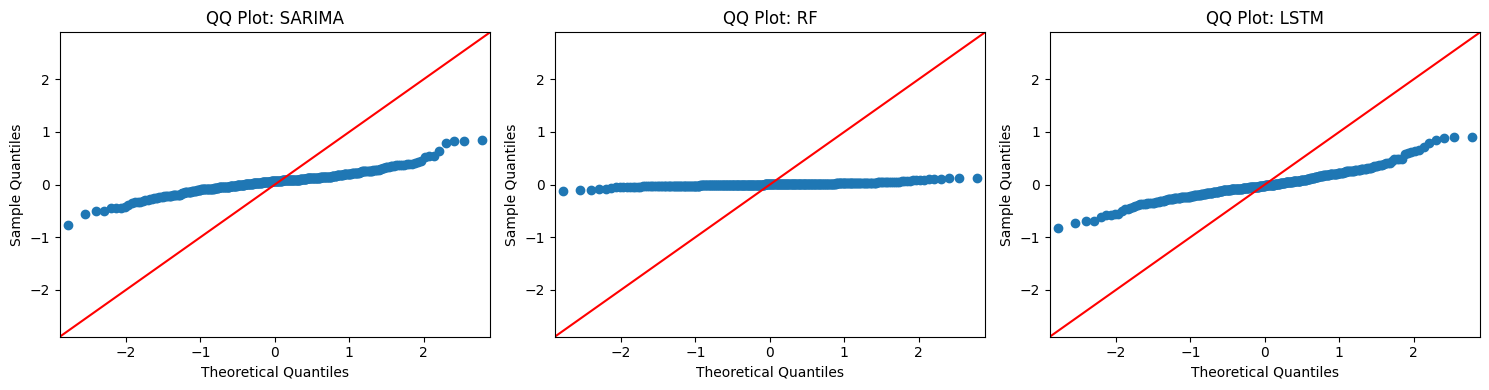

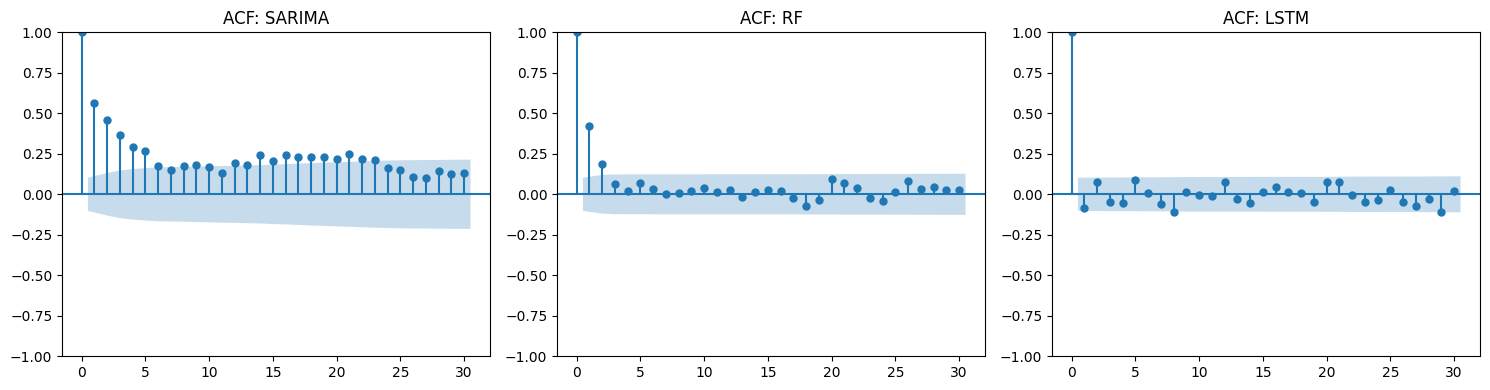

In [37]:
# 1) QQ-plots for normality check
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, resid_df.columns):
    qqplot(resid_df[col], line='45', ax=ax)
    ax.set_title(f'QQ Plot: {col}')
plt.tight_layout()
plt.show()

# 2) ACF of residuals to check autocorrelation
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, resid_df.columns):
    plot_acf(resid_df[col], lags=30, ax=ax, title=f'ACF: {col}')
plt.tight_layout()
plt.show()

### 5.4. Predicted vs. Actual Scatter

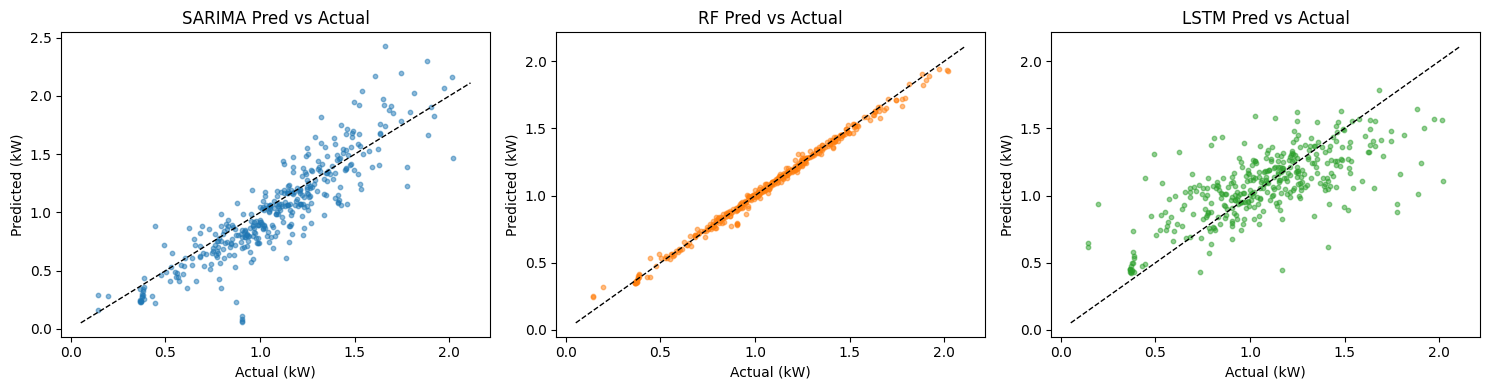

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (pred, name) in zip(axes,
    [(pred_r, 'SARIMA'), (rf_pred, 'RF'), (preds_inv, 'LSTM')]):
    # select actual values and index
    actual_vals = actual if name=='SARIMA' else (y_test if name=='RF' else y_test_inv)
    idx         = idx_test if name=='SARIMA' else (y_test.index if name=='RF' else lstm_idx)
    ax.scatter(actual_vals, pred, alpha=0.5, s=10, color='C'+str(['SARIMA','RF','LSTM'].index(name)))
    ax.plot(ax.get_xlim(), ax.get_xlim(), 'k--', linewidth=1)
    ax.set_title(f'{name} Pred vs Actual')
    ax.set_xlabel('Actual (kW)')
    ax.set_ylabel('Predicted (kW)')
plt.tight_layout()
plt.show()